<a href="https://colab.research.google.com/github/paolavaldes0107-netizen/IA/blob/main/Paola%20Valdes%20Proyecto%20final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# CLASIFICACIÓN DE PISO - UJIIndoorLoc usando ANN (PyTorch)
# Nombre: Paola Valdes
# Materia: Inteligencia artificial

# PASO 0 - LIBRERÍAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

Dispositivo: cpu


In [9]:
# PASO 1 - CARGAR Y EXPLORAR DATASET


df = pd.read_csv("trainingData.csv")

print("Primeras filas:")
display(df.head())

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

print("\nDistribución de FLOOR:")
print(df["FLOOR"].value_counts().sort_index())

Primeras filas:


,WAP001,WAP002,WAP003,WAP004,WAP005,WAP006,WAP007,WAP008,WAP009,WAP010,...,WAP520,LONGITUDE,LATITUDE,FLOOR,BUILDINGID,SPACEID,RELATIVEPOSITION,USERID,PHONEID,TIMESTAMP
0,100,100,100,100,100,100,100,100,100,100,...,100,-7541.2643,4.864921e+06,2,1,106,2,2,23,1371713733
1,100,100,100,100,100,100,100,100,100,100,...,100,-7536.6212,4.864934e+06,2,1,106,2,2,23,1371713691
2,100,100,100,100,100,100,100,-97,100,100,...,100,-7519.1524,4.864950e+06,2,1,103,2,2,23,1371714095
3,100,100,100,100,100,100,100,100,100,100,...,100,-7524.5704,4.864934e+06,2,1,102,2,2,23,1371713807
4,100,100,100,100,100,100,100,100,100,100,...,100,-7632.1436,4.864982e+06,0,0,122,2,11,13,1369909710


Filas: 19937
Columnas: 529

Distribución de FLOOR:
FLOOR
0    4369
1    5002
2    4416
3    5048
4    1102
Name: count, dtype: int64


In [10]:
# PASO 2 - PREPARAR LOS DATOS

cols_to_drop = [
    'LONGITUDE',
    'LATITUDE',
    'SPACEID',
    'RELATIVEPOSITION',
    'USERID',
    'PHONEID',
    'TIMESTAMP'
]

df = df.drop(columns=cols_to_drop)

X = df.drop(columns=["FLOOR"])
y = df["FLOOR"]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (19937, 521)
Shape y: (19937,)


In [11]:
# PASO 3 - PREPROCESAMIENTO WIFI

print("Cantidad de valores 100 antes:", (X == 100).sum().sum())

# reemplazar ausencia de señal
X = X.replace(100, -100)

print("Cantidad de valores 100 después:", (X == 100).sum().sum())

Cantidad de valores 100 antes: 10008477
Cantidad de valores 100 después: 0


In [12]:
# PASO 4 - FUNCIÓN DE CARGA Y DIVISIÓN

def load_data(train_path, test_path, target="FLOOR", random_state=42):

    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    cols_to_drop = [
        'LONGITUDE',
        'LATITUDE',
        'SPACEID',
        'RELATIVEPOSITION',
        'USERID',
        'PHONEID',
        'TIMESTAMP'
    ]

    train_df = train_df.drop(columns=cols_to_drop)
    test_df = test_df.drop(columns=cols_to_drop)

    X_train_full = train_df.drop(columns=[target]).replace(100, -100)
    y_train_full = train_df[target]

    X_test = test_df.drop(columns=[target]).replace(100, -100)
    y_test = test_df[target]

    # división train / val
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=0.20,
        stratify=y_train_full,
        random_state=random_state
    )

    # normalización
    scaler = MinMaxScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    return X_train, X_val, X_test, y_train.values, y_val.values, y_test.values

In [13]:
# cargar datos

X_train, X_val, X_test, y_train, y_val, y_test = load_data(
    "trainingData.csv",
    "validationData.csv"
)

print(X_train.shape, X_val.shape, X_test.shape)

(15949, 521) (3988, 521) (1111, 521)


In [14]:
# CONVERTIR A TENSORES

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor   = torch.tensor(y_val, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

train_ds = TensorDataset(X_train_tensor, y_train_tensor)
val_ds   = TensorDataset(X_val_tensor, y_val_tensor)
test_ds  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32)
test_loader  = DataLoader(test_ds, batch_size=32)

In [15]:
# PASO 5 - MODELOS ANN

# Arquitectura 1
class ANN1(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(521, 128),
            nn.ReLU(),
            nn.Linear(128, 5)
        )
    def forward(self, x):
        return self.net(x)

# Arquitectura 2
class ANN2(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(521, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 5)
        )
    def forward(self, x):
        return self.net(x)

# Arquitectura 3
class ANN3(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(521, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 5)
        )
    def forward(self, x):
        return self.net(x)

# Arquitectura 4
class ANN4(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(521, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 5)
        )
    def forward(self, x):
        return self.net(x)

# Arquitectura 5
class ANN5(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(521, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 5)
        )
    def forward(self, x):
        return self.net(x)

In [16]:
# FUNCIÓN DE ENTRENAMIENTO

def train_model(model, epochs=20):

    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        # entrenamiento
        model.train()
        running_loss = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # validación
        model.eval()
        running_val = 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                loss = criterion(outputs, yb)
                running_val += loss.item()

        val_loss = running_val / len(val_loader)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return train_losses, val_losses

In [17]:
# EVALUACIÓN

def evaluate_model(model):

    model.eval()
    preds = []
    real = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            outputs = model(xb)
            predicted = torch.argmax(outputs, axis=1).cpu().numpy()

            preds.extend(predicted)
            real.extend(yb.numpy())

    acc = accuracy_score(real, preds)
    prec = precision_score(real, preds, average="macro")
    rec = recall_score(real, preds, average="macro")
    f1 = f1_score(real, preds, average="macro")

    return acc, prec, rec, f1

Entrenando: ANN1 Compacta
Epoch 1/20 | Train Loss: 0.3944 | Val Loss: 0.0737
Epoch 2/20 | Train Loss: 0.0472 | Val Loss: 0.0361
Epoch 3/20 | Train Loss: 0.0260 | Val Loss: 0.0255
Epoch 4/20 | Train Loss: 0.0177 | Val Loss: 0.0207
Epoch 5/20 | Train Loss: 0.0132 | Val Loss: 0.0194
Epoch 6/20 | Train Loss: 0.0105 | Val Loss: 0.0173
Epoch 7/20 | Train Loss: 0.0084 | Val Loss: 0.0168
Epoch 8/20 | Train Loss: 0.0072 | Val Loss: 0.0148
Epoch 9/20 | Train Loss: 0.0061 | Val Loss: 0.0169
Epoch 10/20 | Train Loss: 0.0050 | Val Loss: 0.0151
Epoch 11/20 | Train Loss: 0.0047 | Val Loss: 0.0157
Epoch 12/20 | Train Loss: 0.0041 | Val Loss: 0.0147
Epoch 13/20 | Train Loss: 0.0037 | Val Loss: 0.0162
Epoch 14/20 | Train Loss: 0.0033 | Val Loss: 0.0165
Epoch 15/20 | Train Loss: 0.0030 | Val Loss: 0.0159
Epoch 16/20 | Train Loss: 0.0026 | Val Loss: 0.0164
Epoch 17/20 | Train Loss: 0.0030 | Val Loss: 0.0187
Epoch 18/20 | Train Loss: 0.0027 | Val Loss: 0.0166
Epoch 19/20 | Train Loss: 0.0022 | Val Loss: 0.

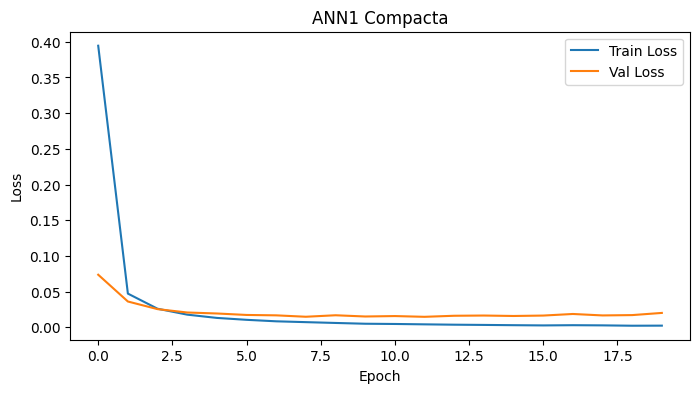

Entrenando: ANN2 Dos Capas
Epoch 1/20 | Train Loss: 0.2149 | Val Loss: 0.0425
Epoch 2/20 | Train Loss: 0.0265 | Val Loss: 0.0218
Epoch 3/20 | Train Loss: 0.0163 | Val Loss: 0.0181
Epoch 4/20 | Train Loss: 0.0148 | Val Loss: 0.0231
Epoch 5/20 | Train Loss: 0.0078 | Val Loss: 0.0206
Epoch 6/20 | Train Loss: 0.0093 | Val Loss: 0.0222
Epoch 7/20 | Train Loss: 0.0065 | Val Loss: 0.0409
Epoch 8/20 | Train Loss: 0.0068 | Val Loss: 0.0216
Epoch 9/20 | Train Loss: 0.0060 | Val Loss: 0.0193
Epoch 10/20 | Train Loss: 0.0081 | Val Loss: 0.0249
Epoch 11/20 | Train Loss: 0.0049 | Val Loss: 0.0219
Epoch 12/20 | Train Loss: 0.0048 | Val Loss: 0.0176
Epoch 13/20 | Train Loss: 0.0025 | Val Loss: 0.0180
Epoch 14/20 | Train Loss: 0.0022 | Val Loss: 0.0182
Epoch 15/20 | Train Loss: 0.0031 | Val Loss: 0.0254
Epoch 16/20 | Train Loss: 0.0084 | Val Loss: 0.0199
Epoch 17/20 | Train Loss: 0.0057 | Val Loss: 0.0175
Epoch 18/20 | Train Loss: 0.0021 | Val Loss: 0.0187
Epoch 19/20 | Train Loss: 0.0043 | Val Loss: 0

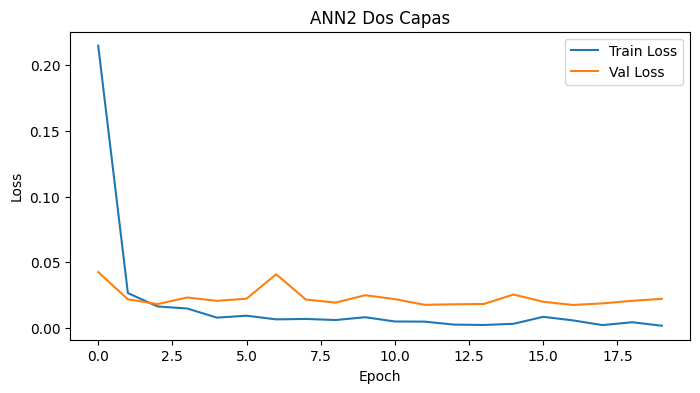

Entrenando: ANN3 Tres Capas
Epoch 1/20 | Train Loss: 0.2239 | Val Loss: 0.0348
Epoch 2/20 | Train Loss: 0.0322 | Val Loss: 0.0322
Epoch 3/20 | Train Loss: 0.0224 | Val Loss: 0.0441
Epoch 4/20 | Train Loss: 0.0166 | Val Loss: 0.0286
Epoch 5/20 | Train Loss: 0.0126 | Val Loss: 0.0193
Epoch 6/20 | Train Loss: 0.0125 | Val Loss: 0.0177
Epoch 7/20 | Train Loss: 0.0051 | Val Loss: 0.0241
Epoch 8/20 | Train Loss: 0.0146 | Val Loss: 0.0351
Epoch 9/20 | Train Loss: 0.0071 | Val Loss: 0.0225
Epoch 10/20 | Train Loss: 0.0061 | Val Loss: 0.0259
Epoch 11/20 | Train Loss: 0.0055 | Val Loss: 0.0217
Epoch 12/20 | Train Loss: 0.0035 | Val Loss: 0.0205
Epoch 13/20 | Train Loss: 0.0133 | Val Loss: 0.0206
Epoch 14/20 | Train Loss: 0.0039 | Val Loss: 0.0237
Epoch 15/20 | Train Loss: 0.0095 | Val Loss: 0.0261
Epoch 16/20 | Train Loss: 0.0046 | Val Loss: 0.0215
Epoch 17/20 | Train Loss: 0.0055 | Val Loss: 0.0256
Epoch 18/20 | Train Loss: 0.0030 | Val Loss: 0.0230
Epoch 19/20 | Train Loss: 0.0017 | Val Loss: 

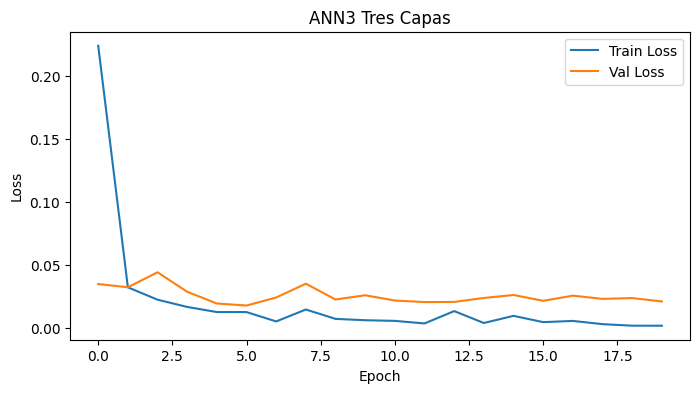

Entrenando: ANN4 Piramide
Epoch 1/20 | Train Loss: 0.1945 | Val Loss: 0.0574
Epoch 2/20 | Train Loss: 0.0366 | Val Loss: 0.0328
Epoch 3/20 | Train Loss: 0.0252 | Val Loss: 0.0207
Epoch 4/20 | Train Loss: 0.0231 | Val Loss: 0.0221
Epoch 5/20 | Train Loss: 0.0133 | Val Loss: 0.0200
Epoch 6/20 | Train Loss: 0.0124 | Val Loss: 0.0541
Epoch 7/20 | Train Loss: 0.0147 | Val Loss: 0.0222
Epoch 8/20 | Train Loss: 0.0055 | Val Loss: 0.0083
Epoch 9/20 | Train Loss: 0.0118 | Val Loss: 0.0173
Epoch 10/20 | Train Loss: 0.0082 | Val Loss: 0.0187
Epoch 11/20 | Train Loss: 0.0124 | Val Loss: 0.0198
Epoch 12/20 | Train Loss: 0.0065 | Val Loss: 0.0179
Epoch 13/20 | Train Loss: 0.0075 | Val Loss: 0.0259
Epoch 14/20 | Train Loss: 0.0078 | Val Loss: 0.0209
Epoch 15/20 | Train Loss: 0.0066 | Val Loss: 0.0229
Epoch 16/20 | Train Loss: 0.0063 | Val Loss: 0.0222
Epoch 17/20 | Train Loss: 0.0102 | Val Loss: 0.0208
Epoch 18/20 | Train Loss: 0.0046 | Val Loss: 0.0227
Epoch 19/20 | Train Loss: 0.0017 | Val Loss: 0.

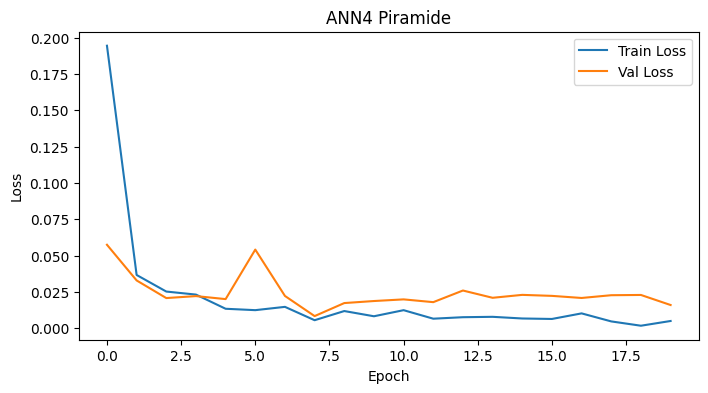

Entrenando: ANN5 Expansiva
Epoch 1/20 | Train Loss: 0.2078 | Val Loss: 0.0462
Epoch 2/20 | Train Loss: 0.0472 | Val Loss: 0.0699
Epoch 3/20 | Train Loss: 0.0417 | Val Loss: 0.1207
Epoch 4/20 | Train Loss: 0.0336 | Val Loss: 0.0198
Epoch 5/20 | Train Loss: 0.0286 | Val Loss: 0.0290
Epoch 6/20 | Train Loss: 0.0143 | Val Loss: 0.0370
Epoch 7/20 | Train Loss: 0.0237 | Val Loss: 0.0924
Epoch 8/20 | Train Loss: 0.0115 | Val Loss: 0.0212
Epoch 9/20 | Train Loss: 0.0200 | Val Loss: 0.0271
Epoch 10/20 | Train Loss: 0.0144 | Val Loss: 0.0233
Epoch 11/20 | Train Loss: 0.0164 | Val Loss: 0.0313
Epoch 12/20 | Train Loss: 0.0124 | Val Loss: 0.0204
Epoch 13/20 | Train Loss: 0.0065 | Val Loss: 0.0202
Epoch 14/20 | Train Loss: 0.0130 | Val Loss: 0.0178
Epoch 15/20 | Train Loss: 0.0189 | Val Loss: 0.0147
Epoch 16/20 | Train Loss: 0.0047 | Val Loss: 0.0485
Epoch 17/20 | Train Loss: 0.0067 | Val Loss: 0.0239
Epoch 18/20 | Train Loss: 0.0087 | Val Loss: 0.0310
Epoch 19/20 | Train Loss: 0.0061 | Val Loss: 0

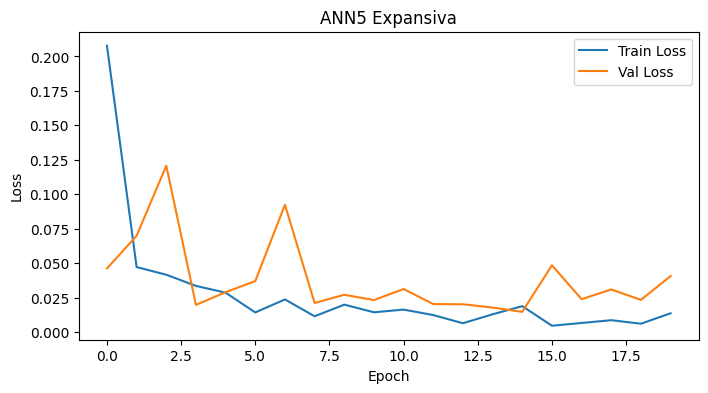

In [18]:
# ENTRENAR TODOS LOS MODELOS

models = {
    "ANN1 Compacta": ANN1(),
    "ANN2 Dos Capas": ANN2(),
    "ANN3 Tres Capas": ANN3(),
    "ANN4 Piramide": ANN4(),
    "ANN5 Expansiva": ANN5()
}

results = []

for name, model in models.items():

    print("="*60)
    print("Entrenando:", name)

    train_loss, val_loss = train_model(model, epochs=20)

    # gráfico pérdidas
    plt.figure(figsize=(8,4))
    plt.plot(train_loss, label="Train Loss")
    plt.plot(val_loss, label="Val Loss")
    plt.title(name)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    acc, prec, rec, f1 = evaluate_model(model)

    results.append([name, acc, prec, rec, f1])

In [19]:
# RESULTADOS FINALES

df_results = pd.DataFrame(
    results,
    columns=["Modelo", "Accuracy", "Precision", "Recall", "F1-score"]
)

df_results.sort_values(by="Accuracy", ascending=False)

,Modelo,Accuracy,Precision,Recall,F1-score
0,ANN1 Compacta,0.879388,0.877446,0.854883,0.862477
4,ANN5 Expansiva,0.860486,0.868749,0.810254,0.832703
2,ANN3 Tres Capas,0.855986,0.856479,0.849395,0.845340
1,ANN2 Dos Capas,0.852385,0.862568,0.825442,0.833542
3,ANN4 Piramide,0.777678,0.705397,0.802218,0.734648


### ¿Cuál considera que fue la mejor arquitectura evaluada? ¿Por qué?

La mejor fue **ANN1 Compacta**, porque obtuvo el mayor accuracy (**0.879**) y también el mejor F1-score. Eso indica que clasificó mejor en general y mantuvo buen equilibrio entre precisión y recall.


### ¿Cuál fue la arquitectura con peor desempeño? ¿A qué cree que se debió su bajo rendimiento?

La peor fue **ANN4 Pirámide**, con accuracy de **0.777**. Creo que al tener muchas capas se volvió más difícil de entrenar y no logró generalizar bien.


### ¿Cómo influye el número de capas ocultas en el comportamiento de la red?

Más capas pueden ayudar a aprender patrones complejos, pero también pueden complicar el entrenamiento. En mis resultados, más profundidad no significó mejor rendimiento.


### ¿Cuál fue la mejor cantidad de épocas para entrenar el mejor modelo? Justifique su elección.

Para ANN1, alrededor de **15 épocas** fue suficiente. Después de eso normalmente la mejora es mínima y se corre riesgo de sobreajuste.


### ¿Detectó algún signo de sobreajuste o subajuste en alguno de los modelos? ¿Cómo lo identificó?

Sí, en los modelos más profundos se notó posible sobreajuste, porque no mejoraron tanto en test aunque eran más complejos. Se identifica cuando entrenan bien pero no generalizan igual.


### ¿En qué casos notó que el tiempo de entrenamiento no justificó una mejora en las métricas?

En **ANN4** y **ANN5**, porque tardan más al tener más capas y no superaron a ANN1 en métricas.


### ¿La arquitectura más profunda fue también la más precisa? ¿Qué conclusiones saca de esto?

No. La más precisa fue ANN1, que era la más simple. Esto demuestra que una red más grande no siempre es mejor.


### ¿Qué métrica considera más importante en este contexto (accuracy, precision, recall, F1-score) y por qué?

Considero que el **F1-score**, porque combina precision y recall. Es mejor cuando hay clases desbalanceadas, como en este dataset.
